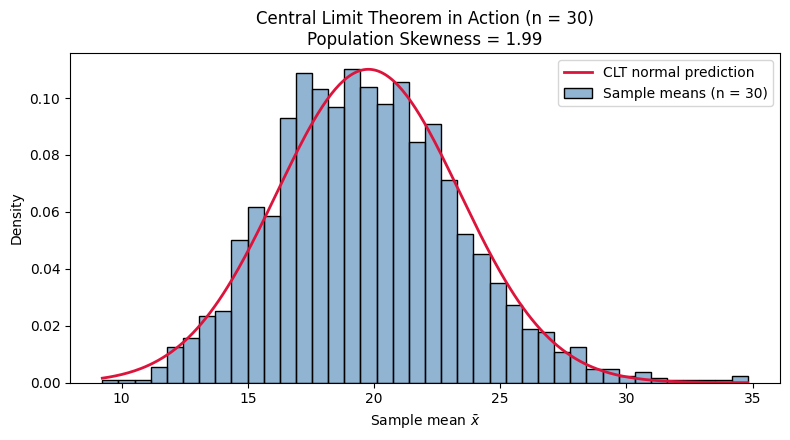

In [1]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Step 1: Generate a right-skewed population (exponential, mean = 20)
population = rng.exponential(scale=20, size=10_000)
mu = population.mean()
sigma = population.std()

# Step 2: Draw 2000 samples of size n = 30 and compute each mean
n = 30
sample_means = np.array([
    rng.choice(population, size=n, replace=True).mean()
    for _ in range(2000)
])

# Step 3: Plot the histogram with seaborn and overlay the CLT normal curve
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(sample_means, bins=40, stat="density",
             color="steelblue", alpha=0.6, ax=ax,
             label="Sample means (n = 30)")

# Theoretical CLT normal curve: N(mu, sigma^2 / n)
x = np.linspace(sample_means.min(), sample_means.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma / np.sqrt(n)),
        color="crimson", linewidth=2, label="CLT normal prediction")

ax.set_xlabel(r"Sample mean $\bar{x}$")
ax.set_ylabel("Density")
ax.set_title(f"Central Limit Theorem in Action (n = {n})\n"
             f"Population Skewness = {stats.skew(population):.2f}")
ax.legend()
plt.tight_layout()
plt.show()